# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [2]:
df = pd.read_csv("data.csv")

# Display first 5 rows
df.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


# Basic Dataset Understanding

In [3]:
# Shape of dataset

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(30697, 25)


In [4]:
# Column names

print(df.columns)

Index(['action_type', 'combined_shot_type', 'game_event_id', 'game_id', 'lat',
       'loc_x', 'loc_y', 'lon', 'minutes_remaining', 'period', 'playoffs',
       'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag',
       'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range',
       'team_id', 'team_name', 'game_date', 'matchup', 'opponent', 'shot_id'],
      dtype='object')


In [5]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

In [6]:
# Statistical summary

df.describe()

,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id
count,30697.000000,3.069700e+04,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,30697.000000,25697.000000,3.069700e+04,30697.000000
mean,249.190800,2.476407e+07,33.953192,7.110499,91.107535,-118.262690,4.885624,2.519432,0.146562,28.365085,13.437437,0.446161,1.610613e+09,15349.000000
std,150.003712,7.755175e+06,0.087791,110.124578,87.791361,0.110125,3.449897,1.153665,0.353674,17.478949,9.374189,0.497103,0.000000e+00,8861.604943
min,2.000000,2.000001e+07,33.253300,-250.000000,-44.000000,-118.519800,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.610613e+09,1.000000
25%,110.000000,2.050008e+07,33.884300,-68.000000,4.000000,-118.337800,2.000000,1.000000,0.000000,13.000000,5.000000,0.000000,1.610613e+09,7675.000000
50%,253.000000,2.090035e+07,33.970300,0.000000,74.000000,-118.269800,5.000000,3.000000,0.000000,28.000000,15.000000,0.000000,1.610613e+09,15349.000000
75%,368.000000,2.960047e+07,34.040300,95.000000,160.000000,-118.174800,8.000000,3.000000,0.000000,43.000000,21.000000,1.000000,1.610613e+09,23023.000000
max,659.000000,4.990009e+07,34.088300,248.000000,791.000000,-118.021800,11.000000,7.000000,1.000000,59.000000,79.000000,1.000000,1.610613e+09,30697.000000


In [7]:
cols_to_drop = ['lat', 'lon', 'game_event_id', 'game_date']
df = df.drop(cols_to_drop, axis=1)

In [8]:
df = df[df['shot_made_flag'].notnull()]

# Missing Value Analysis

In [9]:
# Missing values

missing_values = df.isnull().sum()

print(missing_values)

action_type           0
combined_shot_type    0
game_id               0
loc_x                 0
loc_y                 0
minutes_remaining     0
period                0
playoffs              0
season                0
seconds_remaining     0
shot_distance         0
shot_made_flag        0
shot_type             0
shot_zone_area        0
shot_zone_basic       0
shot_zone_range       0
team_id               0
team_name             0
matchup               0
opponent              0
shot_id               0
dtype: int64


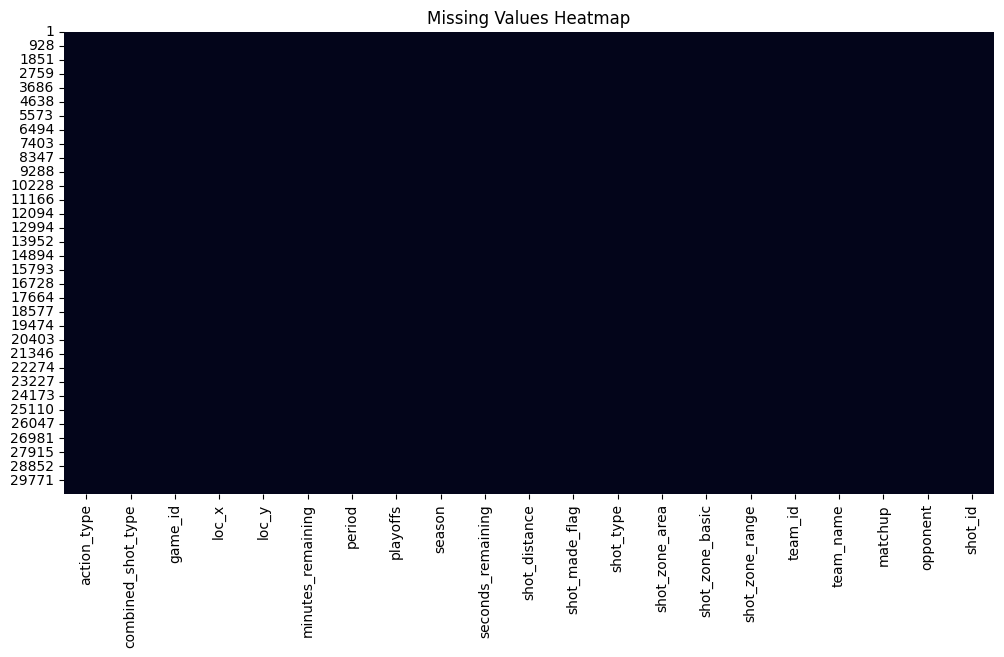

In [10]:
# Visualize missing values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

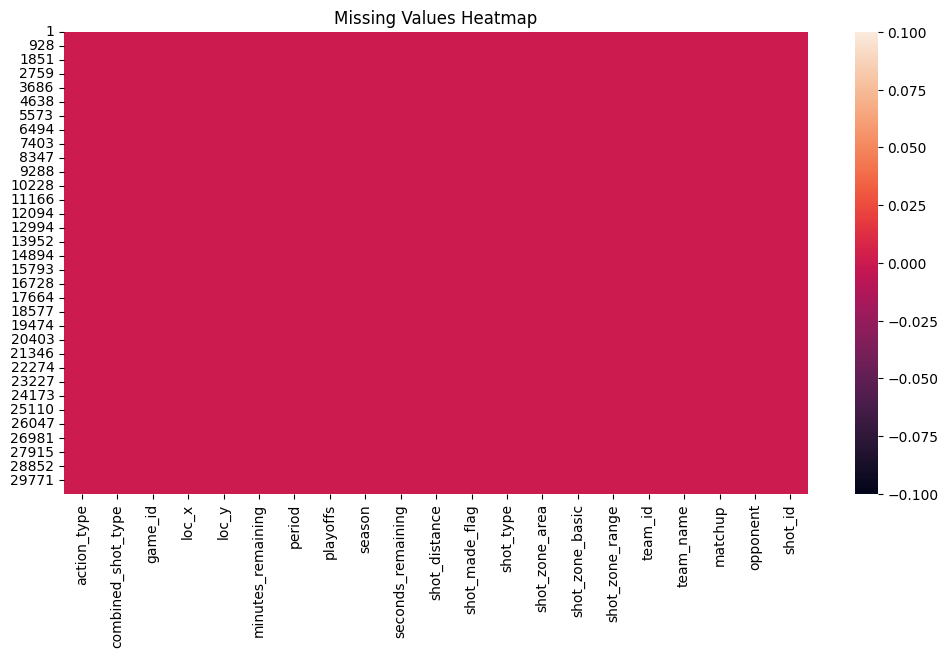

In [11]:
# Visualize missing values

plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=True)

plt.title("Missing Values Heatmap")
plt.show()

# Duplicate Value Check

In [17]:
# Duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [18]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


# Target Variable Analysis

### Assume target column:
shot_result

### Where:

- 1 = Made
- 0 = Missed

In [19]:
print(df.columns.tolist())

['action_type', 'combined_shot_type', 'game_id', 'loc_x', 'loc_y', 'minutes_remaining', 'period', 'playoffs', 'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'team_id', 'team_name', 'matchup', 'opponent', 'shot_id']


# Exploratory Data Analysis (EDA)

### Shot Distance Analysis

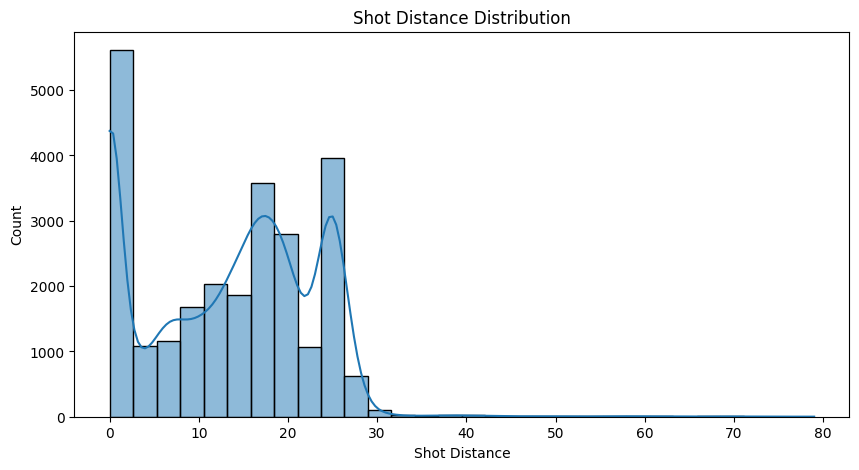

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df['shot_distance'], bins=30, kde=True)

plt.title("Shot Distance Distribution")
plt.xlabel("Shot Distance")
plt.show()

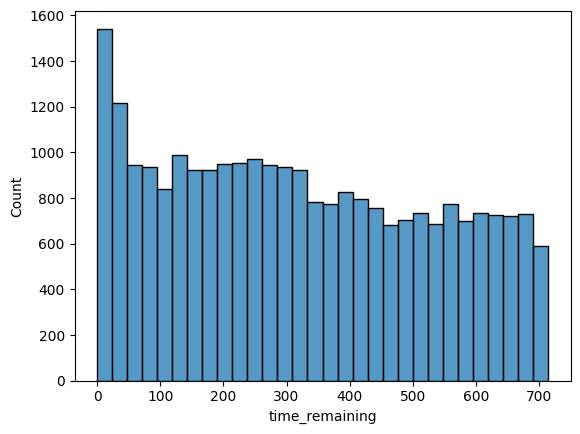

In [21]:
df.loc[:, 'time_remaining'] = df['minutes_remaining'] * 60 + df['seconds_remaining']

df = df[df['shot_made_flag'].notnull()].copy()
sns.histplot(df['time_remaining'], bins=30)
plt.show()

### Shot Type Analysis

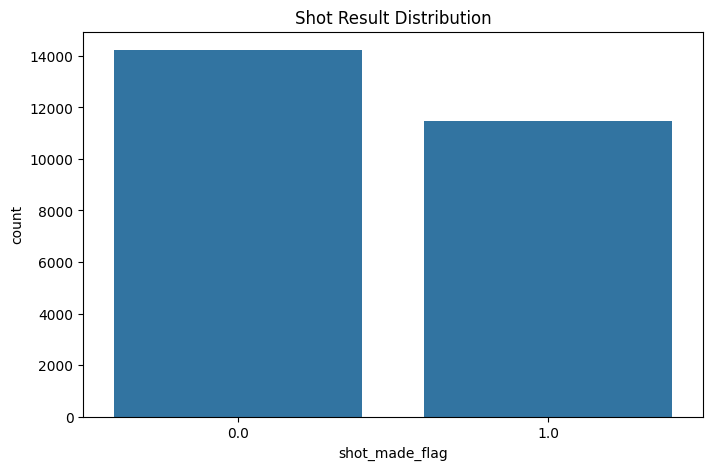

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(x='shot_made_flag', data=df)

plt.title("Shot Result Distribution")
plt.show()

### Shot Success vs Distance

In [23]:
# Clean column names

df.columns = df.columns.str.strip()

# Convert to lowercase

df.columns = df.columns.str.lower()

print(df.columns.tolist())

['action_type', 'combined_shot_type', 'game_id', 'loc_x', 'loc_y', 'minutes_remaining', 'period', 'playoffs', 'season', 'seconds_remaining', 'shot_distance', 'shot_made_flag', 'shot_type', 'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'team_id', 'team_name', 'matchup', 'opponent', 'shot_id', 'time_remaining']


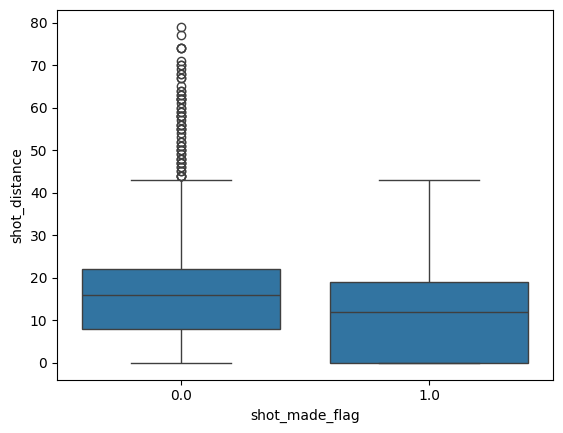

In [24]:
sns.boxplot(x='shot_made_flag', y='shot_distance', data=df)
plt.show()

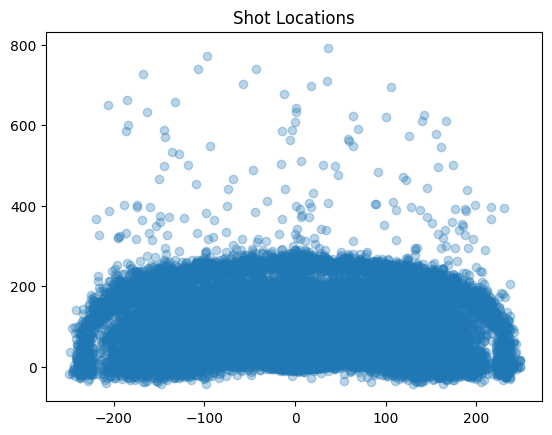

In [25]:
plt.scatter(df['loc_x'], df['loc_y'], alpha=0.3)
plt.title("Shot Locations")
plt.show()

# Feature Engineering


In [26]:
df['time_remaining'] = df['minutes_remaining'] * 60 + df['seconds_remaining']

df['shot_distance_cat'] = pd.cut(df['shot_distance'],
                                bins=[0, 10, 20, 50],
                                labels=['close', 'mid', 'far'])

In [27]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,game_id,loc_x,loc_y,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,shot_id,time_remaining
game_id,1.000000,-0.012944,-0.011361,0.009581,0.005061,0.917898,-0.009029,-0.027247,-0.001612,NaN,0.761232,0.008768
loc_x,-0.012944,1.000000,-0.017578,0.006624,-0.030059,-0.007751,0.001512,0.022307,-0.000848,NaN,-0.012453,0.006714
loc_y,-0.011361,-0.017578,1.000000,-0.077399,0.039737,0.000857,-0.057766,0.818124,-0.148070,NaN,0.033476,-0.081826
minutes_remaining,0.009581,0.006624,-0.077399,1.000000,-0.047021,0.009583,0.024232,-0.064159,0.028342,NaN,-0.008251,0.996458
period,0.005061,-0.030059,0.039737,-0.047021,1.000000,0.003905,0.007153,0.047311,-0.032152,NaN,-0.003357,-0.046157
playoffs,0.917898,-0.007751,0.000857,0.009583,0.003905,1.000000,-0.005951,-0.007751,-0.001257,NaN,0.612991,0.009029
seconds_remaining,-0.009029,0.001512,-0.057766,0.024232,0.007153,-0.005951,1.000000,-0.055875,0.030804,NaN,-0.004833,0.108218
shot_distance,-0.027247,0.022307,0.818124,-0.064159,0.047311,-0.007751,-0.055875,1.000000,-0.198242,NaN,0.020464,-0.068501
shot_made_flag,-0.001612,-0.000848,-0.148070,0.028342,-0.032152,-0.001257,0.030804,-0.198242,1.000000,NaN,-0.013016,0.030775
team_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Correlation Heatmap

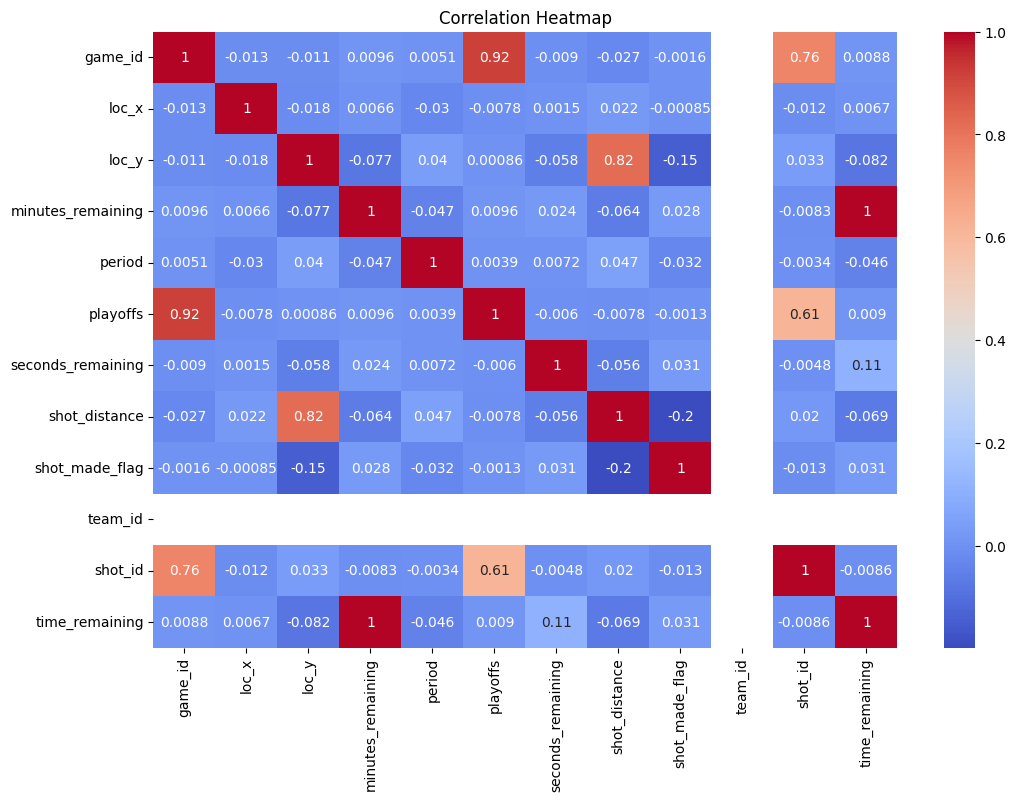

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [29]:
corr_target = corr_matrix['shot_made_flag'].sort_values(ascending=False)

print(corr_target)

shot_made_flag       1.000000
seconds_remaining    0.030804
time_remaining       0.030775
minutes_remaining    0.028342
loc_x               -0.000848
playoffs            -0.001257
game_id             -0.001612
shot_id             -0.013016
period              -0.032152
loc_y               -0.148070
shot_distance       -0.198242
team_id                   NaN
Name: shot_made_flag, dtype: float64


In [30]:
# Clutch situation feature

df['clutch_shot'] = np.where(
    df['seconds_remaining'] <= 120,
    1,
    0
)

df[['seconds_remaining',
    'clutch_shot']].head()

,seconds_remaining,clutch_shot
1,22,1
2,45,1
3,52,1
4,19,1
5,32,1


In [31]:
df['shot_difficulty'] = (
    df['shot_distance'] * 0.7
    +
    df['playoffs'] * 5
)

df[['shot_distance',
    'playoffs',
    'shot_difficulty']].head()

,shot_distance,playoffs,shot_difficulty
1,15,0,10.5
2,16,0,11.2
3,22,0,15.4
4,0,0,0.0
5,14,0,9.8


In [13]:
df['shot_difficulty'] = (
    df['shot_distance'] * 0.5
    +
    df['period'] * 1.5
    +
    df['playoffs'] * 5
)

In [14]:
df['court_distance'] = np.sqrt(
    (df['loc_x'] ** 2)
    +
    (df['loc_y'] ** 2)
)

df[['loc_x',
    'loc_y',
    'court_distance']].head()

,loc_x,loc_y,court_distance
1,-157,0,157.000000
2,-101,135,168.600119
3,138,175,222.865430
4,0,0,0.000000
5,-145,-11,145.416643


# Encoding Categorical Variables

In [15]:
# Identify categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['action_type', 'combined_shot_type', 'season', 'shot_type',
       'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'team_name',
       'matchup', 'opponent'],
      dtype='object')


In [16]:
# Apply One Hot Encoding

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,game_id,loc_x,loc_y,minutes_remaining,period,playoffs,seconds_remaining,shot_distance,shot_made_flag,team_id,...,opponent_PHI,opponent_PHX,opponent_POR,opponent_SAC,opponent_SAS,opponent_SEA,opponent_TOR,opponent_UTA,opponent_VAN,opponent_WAS
1,20000012,-157,0,10,1,0,22,15,0.0,1610612747,...,False,False,True,False,False,False,False,False,False,False
2,20000012,-101,135,7,1,0,45,16,1.0,1610612747,...,False,False,True,False,False,False,False,False,False,False
3,20000012,138,175,6,1,0,52,22,0.0,1610612747,...,False,False,True,False,False,False,False,False,False,False
4,20000012,0,0,6,2,0,19,0,1.0,1610612747,...,False,False,True,False,False,False,False,False,False,False
5,20000012,-145,-11,9,3,0,32,14,0.0,1610612747,...,False,False,True,False,False,False,False,False,False,False


# Feature and Target Split

In [17]:
# Target variable

y = df['shot_made_flag']

# Feature variables

X = df.drop('shot_made_flag', axis=1)

print(X.shape)
print(y.shape)

(25697, 22)
(25697,)


In [18]:
X.dtypes    # check the data  type

action_type            object
combined_shot_type     object
game_id                 int64
loc_x                   int64
loc_y                   int64
minutes_remaining       int64
period                  int64
playoffs                int64
season                 object
seconds_remaining       int64
shot_distance           int64
shot_type              object
shot_zone_area         object
shot_zone_basic        object
shot_zone_range        object
team_id                 int64
team_name              object
matchup                object
opponent               object
shot_id                 int64
shot_difficulty       float64
court_distance        float64
dtype: object

## Identify Categorical Columns

In [19]:
categorical_cols = X.select_dtypes(
    include=['object']
).columns

print(categorical_cols)

Index(['action_type', 'combined_shot_type', 'season', 'shot_type',
       'shot_zone_area', 'shot_zone_basic', 'shot_zone_range', 'team_name',
       'matchup', 'opponent'],
      dtype='object')


# One Hot Encoding

- Convert categorical columns into numerical values.


In [20]:

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print(X_encoded.shape)

(25697, 211)


# Train Test Split

## Professional split:

- 80% training
- 20% testing

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(20557, 211)
(5140, 211)


# Feature Scaling

Needed for:

- Logistic Regression
- SVM
- Neural Networks

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model

## 11.1 Import Model

In [23]:
from sklearn.linear_model import LogisticRegression

## Train Model

In [24]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred_lr = lr_model.predict(X_test_scaled) # make prediction


# Evaluate Logistic Regression

In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Accuracy: 0.6811284046692607
Precision: 0.7174220963172805
Recall: 0.4496227252552153
F1 Score: 0.5527967257844475


# Confusion Matrix

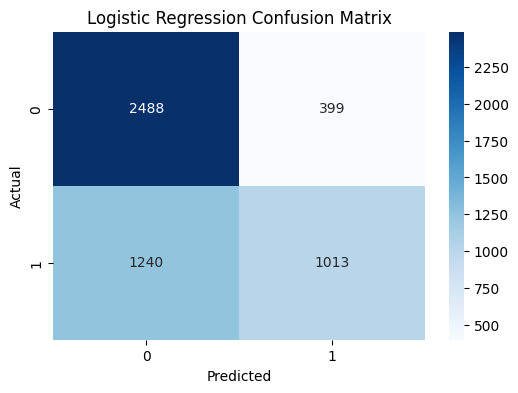

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)     # Train Model

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
y_pred_rf = rf_model.predict(X_test)   # prediction

In [31]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Accuracy: 0.6844357976653697
Precision: 0.7113194909578031
Recall: 0.47137150466045274
F1 Score: 0.5670048051254671


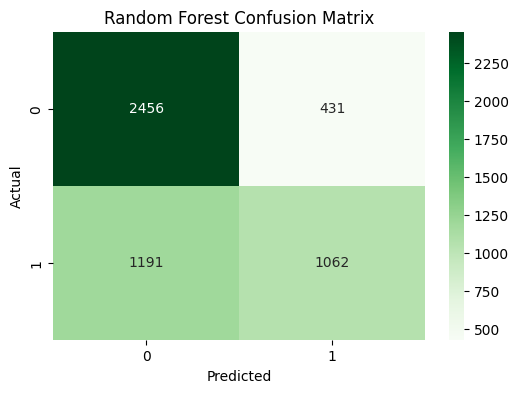

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Feature Importance

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
36,action_type_Jump Shot,0.171965
66,combined_shot_type_Dunk,0.065205
11,court_distance,0.057333
37,action_type_Layup Shot,0.051380
7,shot_distance,0.041074
68,combined_shot_type_Jump Shot,0.038229
100,shot_zone_basic_Restricted Area,0.037540
51,action_type_Running Jump Shot,0.035565
2,loc_y,0.032639
10,shot_difficulty,0.029675


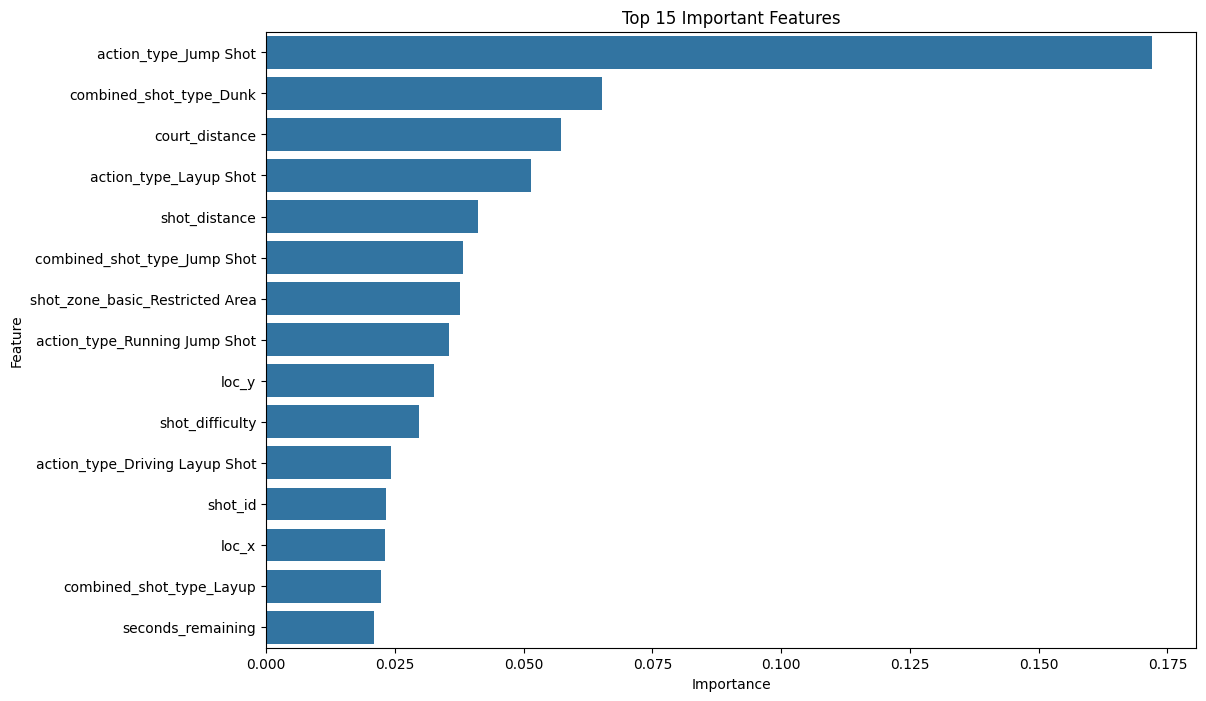

In [34]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(15)
)

plt.title("Top 15 Important Features")

plt.show()

# ROC AUC Score

In [35]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_pred_rf)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.6610407921639638


# Classification Report

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

         0.0       0.67      0.85      0.75      2887
         1.0       0.71      0.47      0.57      2253

    accuracy                           0.68      5140
   macro avg       0.69      0.66      0.66      5140
weighted avg       0.69      0.68      0.67      5140



In [37]:
# !pip install xgboost

In [38]:
from xgboost import XGBClassifier

In [39]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)   # Train XG Boost

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
y_pred_xgb = xgb_model.predict(X_test)

In [41]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("Precision:",
      precision_score(y_test, y_pred_xgb))

print("Recall:",
      recall_score(y_test, y_pred_xgb))

print("F1 Score:",
      f1_score(y_test, y_pred_xgb))

Accuracy: 0.677431906614786
Precision: 0.6930564568462038
Recall: 0.474034620505992
F1 Score: 0.5629942013705851


In [42]:
models = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [

        accuracy_score(y_test, y_pred_lr),

        accuracy_score(y_test, y_pred_rf),

        accuracy_score(y_test, y_pred_xgb)
    ]
})

models          # Model comparison

,Model,Accuracy
0,Logistic Regression,0.681128
1,Random Forest,0.684436
2,XGBoost,0.677432


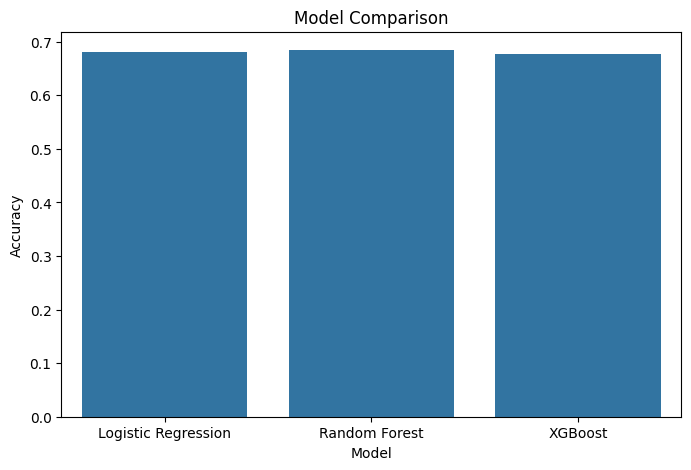

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)

plt.title("Model Comparison")

plt.show()

In [44]:
import joblib

joblib.dump(
    rf_model,
    'nba_shot_prediction_model.pkl'
)

print("Model Saved Successfully")

Model Saved Successfully


In [45]:
joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Scaler Saved Successfully")

Scaler Saved Successfully


# Hyperparameter Tuning

### Currently:

- models use default/basic parameters.

### Client expects:

- optimized models.

In [46]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=params,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

print(rf_tuned.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END max_depth=5, min_samples_split=10, n_estimators=300; total time=   1.6s
[CV] END max_depth=5, min_samples_split=10, n_estimators=300; total time=   1.6s
[CV] END max_depth=5, min_samples_split=10, n_estimators=300; total time=   1.5s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   1.8s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   1.8s
[CV] END max_depth=10, min_samples_split=5, n_estimators=200; total time=   2.1s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=15, min_samples_split=5, n_estimators=100; total time=   1.2s
[CV] END max_depth=15, min_samples_split=5, n_estimators=100; total time=   1.2s
[CV] END max_depth=15, min_samples_split=5, n_est

In [47]:
# !pip install shap

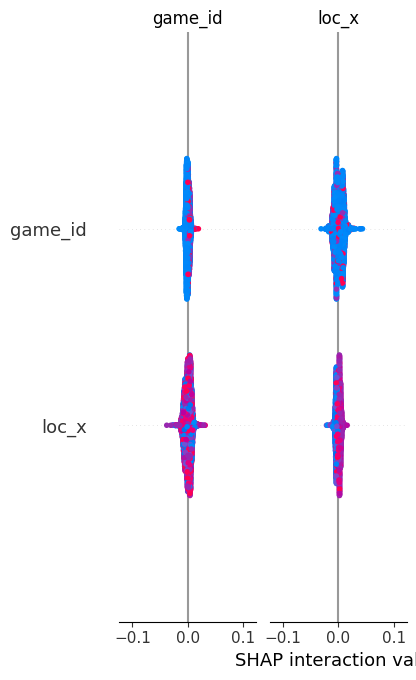

In [48]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [49]:
# !pip install fastapi
# !pip install uvicorn
# !pip install fastapi uvicorn

In [53]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "NBA Shot Prediction API"}